In [ ]:
# Import modules
import os
import sys
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import random
import torch.nn.functional as F
import copy
import matplotlib.pyplot as plt
import numpy as np
import time
import io
import json

**Obtention de la dernière version de torchao**

In [ ]:
!pip install -U torchao


In [ ]:
pip show torchao

Name: torchao
Version: 0.15.0
Summary: Package for applying ao techniques to GPU models
Home-page: https://github.com/pytorch/ao
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 


In [ ]:
#Import modules for quantization
from torchao.quantization import quantize_, Int8DynamicActivationInt4WeightConfig
from torchao.quantization.qat import QATConfig


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load CIFAR-10 Dataset
d = './data'
if not os.path.exists(d):
    os.mkdir(d)

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_set = datasets.CIFAR10(root=d, train=True, transform=train_transforms, download=True)
test_set = datasets.CIFAR10(root=d, train=False, transform=test_transforms, download=True)

batch_size = 32
global_train_loader = torch.utils.data.DataLoader(
                 dataset=train_set,
                 batch_size=batch_size,
                 shuffle=True)
global_test_loader = torch.utils.data.DataLoader(
                dataset=test_set,
                batch_size=batch_size,
                shuffle=False)

Voici le nombre de labels dans la classe 0 : 5000 et les indices sont [   29    30    35 ... 49941 49992 49994]
Voici le nombre de labels dans la classe 1 : 5000 et les indices sont [    4     5    32 ... 49993 49998 49999]
Voici le nombre de labels dans la classe 2 : 5000 et les indices sont [    6    13    18 ... 49987 49991 49995]
Voici le nombre de labels dans la classe 3 : 5000 et les indices sont [    9    17    21 ... 49979 49982 49983]
Voici le nombre de labels dans la classe 4 : 5000 et les indices sont [    3    10    20 ... 49981 49984 49990]
Voici le nombre de labels dans la classe 5 : 5000 et les indices sont [   27    40    51 ... 49964 49980 49988]
Voici le nombre de labels dans la classe 6 : 5000 et les indices sont [    0    19    22 ... 49962 49966 49996]
Voici le nombre de labels dans la classe 7 : 5000 et les indices sont [    7    11    12 ... 49965 49978 49986]
Voici le nombre de labels dans la classe 8 : 5000 et les indices sont [    8    62    69 ... 49968 49976

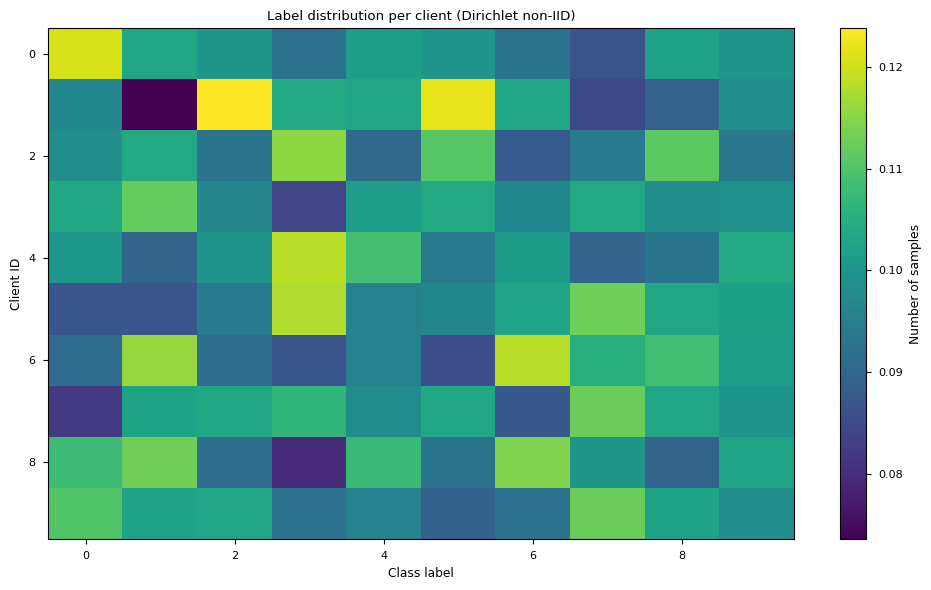

[np.int64(4914), np.int64(5420), np.int64(4917), np.int64(4676), np.int64(5394), np.int64(4903), np.int64(4797), np.int64(4651), np.int64(5062), np.int64(5266)]


In [ ]:
from collections import defaultdict
from torch.utils.data import Subset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt


def Dirichlet(labels, alpha, num_clients) :
    n_classes = len(np.unique(labels))
    client_indices = defaultdict(list)

    np.random.seed(42)
    torch.manual_seed(42)

    for c in range(n_classes):
        labels = np.array(train_set.targets)
        idx = np.where(labels == c)[0]
        print("Voici le nombre de labels dans la classe", c, ":", len(idx), "et les indices sont", idx )
        np.random.shuffle(idx)
        proportions = np.random.dirichlet([alpha] * num_clients)
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        splits = np.split(idx, proportions)


        for client_id, split in enumerate(splits):
            client_indices[client_id].extend(split)

    for cid in range(num_clients):
        if len(client_indices[cid]) == 0:
            random_idx = np.random.randint(0, len(labels))
            client_indices[cid].append(random_idx)
            print(f"Warning: Client {cid} était vide, un échantillon a été ajouté.")


    return client_indices



def count_labels_per_client(train_set, client_indices, num_classes=10):
    counts = np.zeros((len(client_indices), num_classes), dtype=int)

    for cid, indices in client_indices.items():
        labels = np.array(train_set.targets)[indices]
        counter = Counter(labels)
        for cls, cnt in counter.items():
            counts[cid, cls] = cnt

    return counts


def plot_label_distribution(counts):
    plt.figure(figsize=(10, 6))
    plt.imshow(counts, aspect="auto")
    plt.colorbar(label="Number of samples")
    plt.xlabel("Class label")
    plt.ylabel("Client ID")
    plt.title("Label distribution per client (Dirichlet non-IID)")
    plt.tight_layout()
    plt.show()



def build_client_datasets(
    num_clients=10,
    alpha=0.5,
    batch_size=32,
):
    labels = train_set.targets
    client_indices = Dirichlet(labels, alpha, num_clients)

    counts = count_labels_per_client(train_set, client_indices, num_classes=10)
    print(counts)
    counts_norm = counts / counts.sum(axis=1, keepdims=True)
    plot_label_distribution(counts_norm)

    i = 0
    clients = []

    for cid, indices in client_indices.items():

        model = models.resnet18(weights=None, num_classes=10).to(device)

        number_sample = 0
        for j in range (len(counts[i])) :
          number_sample += counts[i][j]


        loader = torch.utils.data.DataLoader(
                  dataset= Subset(train_set, indices) ,
                  batch_size=batch_size,
                  shuffle=True,
                  drop_last=True) #supprime le batch s'il fait moinsde 32 images j'en avais besoin pour éviter des erreurs de batch de size 1

        client = {"client_id": i,
            "local_dataset": loader,
            "local_model" : model,
            "optimizer": optim.SGD(model.parameters(), lr=0.01, momentum=0.9),
            "number_sample" : number_sample}

        clients.append(client)
        i += 1


    return clients


clients = build_client_datasets(    num_clients=10,
    alpha=65,
    batch_size=32)

number_sample_clients = [x["number_sample"] for x in clients]
print(number_sample_clients)

In [ ]:
def quantize_tensor(tensor, bits=8):

    qmin = -(2 ** (bits - 1))
    qmax = (2 ** (bits - 1)) - 1

    max_val = tensor.abs().max()


    scale = max_val / qmax if max_val != 0 else 1.0

    q_tensor = (tensor / scale).round().clamp(qmin, qmax).to(torch.int8)

    return q_tensor, scale

def quantize_model_state_dict(state_dict, bits=8):
    q_state = {}
    scales = {}

    for name, tensor in state_dict.items():
        if "bn" in name or "bias" in name or tensor.dim() < 2:
            q_state[name] = tensor
            scales[name] = None
        elif tensor.dtype == torch.float32:
            q_tensor, scale = quantize_tensor(tensor, bits)
            q_state[name] = q_tensor
            scales[name] = scale
        else:

            q_state[name] = tensor
            scales[name] = None

    return q_state, scales


def dequantize_tensor(q_tensor, scale):
    return q_tensor.float() * scale


def dequantize_model_state_dict(q_state, scales):
    fp32_state = {}

    for name, q_tensor in q_state.items():
        scale = scales[name]

        if scale is not None:
            fp32_state[name] = dequantize_tensor(q_tensor, scale)
        else:
            fp32_state[name] = q_tensor

    return fp32_state

In [ ]:


def client_load_model(client, model):
    client["local_model"].load_state_dict(model.state_dict())

def client_local_training(client):
    criterion = nn.CrossEntropyLoss()
    optimizer = client["optimizer"]
    dataset = client["local_dataset"]
    model = client["local_model"].to(device)
    model.train()

    for batch_idx, (x, target) in enumerate(dataset):
        x, target = x.to(device), target.to(device)
        out = model(x)
        loss = criterion(out, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return client["local_model"].state_dict()

def client_send_update(client):
    fp32 = client["local_model"].state_dict()
    q_state, scales = quantize_model_state_dict(fp32)
    return q_state, scales


def server_aggregate_quantized(q_updates, client_id):
  fp32_models = []
  number_sample = [number_sample_clients[i] for i in client_id]
  total_sample = sum(number_sample)

  if len(q_updates) == 0:
    return None

  for q_state, scales in q_updates:
      fp32_model = dequantize_model_state_dict(q_state, scales)
      fp32_models.append(fp32_model)

  averaged_model = copy.deepcopy(fp32_models[0])
  with torch.no_grad():
    for k in averaged_model.keys():
        i = 0
        somme = 0
        for m in fp32_models :
          somme += m[k] * number_sample[i]
          i += 1
        averaged_model[k]  = somme / total_sample
  return averaged_model

def evaluate(model, dataset):
    model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, total, correct = 0, 0, 0

    with torch.no_grad():
        for x, target in dataset:
            x, target = x.to(device), target.to(device)
            out = model(x)
            loss = criterion(out, target)
            _, pred_label = torch.max(out, 1)
            total_loss += loss.item()
            total += x.size(0)
            correct += (pred_label == target).sum().item()

    avg_loss = total_loss / len(dataset)
    acc = correct / total
    print(f"loss: {avg_loss:.4f}, acc: {acc:.4f}")
    return avg_loss, acc

def get_model_size(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    size_MB = buffer.getbuffer().nbytes / 1e6
    return size_MB

def get_quantized_model_size(q_state):
    buffer = io.BytesIO()
    torch.save(q_state, buffer)
    size_MB = buffer.getbuffer().nbytes / 1e6
    return size_MB

def federated_learning_loop_int8(save_dir):
    # Set seed
    torch.manual_seed(42)
    global_model = models.resnet18(weights=None, num_classes=10).to(device)

    client_participation_fraction = 0.2
    rounds = 750
    eval_interval = 10  # Measure costly metrics every X rounds
    save_interval = 50  # Save model every Y rounds
    os.makedirs(save_dir, exist_ok=True)

    metrics = {
        "round": [],
        "loss": [],
        "accuracy": [],
        "round_time": [],
        "model_size": []
    }
    best_acc = 0.0

    for r in range(rounds):
        print(f"\nRound {r+1}")

        # Start the timer
        start_time = time.time()

        # Broadcast global model to clients
        for c in clients:
            client_load_model(c, global_model)

        q_updates = []
        client_id = []

        # Selected clients perform local training
        for c in clients:
            if random.random() <= client_participation_fraction:
              client_local_training(c)
              q_updates.append(client_send_update(c))
              client_id.append(c["client_id"])


        # Aggregate models from participating clients
        if len(q_updates) == 0:
          print("No client participated this round — keeping global model.")
          continue

        else:
          aggregated_model = server_aggregate_quantized(q_updates, client_id)

        # Update global model
        global_model.load_state_dict(aggregated_model)

        # Stop the timer before computing the metrics
        round_time = time.time() - start_time

        # Evaluation
        print("Time evaluation")
        t0 = time.time()
        loss, acc = evaluate(global_model, global_test_loader)
        t1 = time.time()
        print(f"Durée de evaluate : {t1 - t0:.3f} s")

        if (r + 1) % eval_interval == 0 or r == 0 or r == rounds - 1:
            model_size = get_model_size(global_model)
        else:
            model_size = metrics["model_size"][-1]

        # Save metrics for plotting
        metrics["round"].append(r+1)
        metrics["round_time"].append(round_time)
        metrics["loss"].append(loss)
        metrics["accuracy"].append(acc)
        metrics["model_size"].append(model_size)

        total_bytes = 0
        for q_state, scales in q_updates:
            buffer = io.BytesIO()
            torch.save(q_state, buffer)
            total_bytes += buffer.getbuffer().nbytes
        print(f"Total sent this round (INT8): {total_bytes/1e6:.3f} MB")

        # Save model periodically
        if (r + 1) % save_interval == 0:
          example_q_state, example_scales = client_send_update(clients[0])
          quantized_size = get_quantized_model_size(example_q_state)
          print(f"INT8 model update size: {quantized_size:.3f} MB")

        # Save best model so far
        if acc > best_acc:
            best_acc = acc
            torch.save(global_model.state_dict(), f"{save_dir}/best_model.pth")
            print(f"New best model saved (acc={acc:.4f})")

    # Save final model
    #torch.save(global_model.state_dict(), f"{save_dir}/final_model.pth")
    print("Final model saved")

    return metrics

In [ ]:
def plot_metrics(metrics, filename):
    rounds = np.array(metrics["round"])
    loss = np.array(metrics["loss"])
    acc = np.array(metrics["accuracy"])
    round_time = np.array(metrics["round_time"])
    model_size = np.array(metrics["model_size"])

    plt.style.use('seaborn-v0_8-paper')

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    # Loss
    axes[0].plot(rounds, loss, color='tab:blue', linewidth=2)
    axes[0].set_title("Global Model Loss", fontsize=15)
    axes[0].set_xlabel("Round", fontsize=13)
    axes[0].set_ylabel("Loss", fontsize=13)
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(rounds, acc, color='tab:orange', linewidth=2)
    axes[1].set_title("Global Model Accuracy", fontsize=15)
    axes[1].set_xlabel("Round", fontsize=13)
    axes[1].set_ylabel("Accuracy", fontsize=13)
    axes[1].grid(True)

    # Round time
    axes[2].plot(rounds, round_time, color='tab:green', linewidth=2)
    axes[2].set_title("Round Duration", fontsize=15)
    axes[2].set_xlabel("Round", fontsize=13)
    axes[2].set_ylabel("Time (s)", fontsize=13)
    axes[2].grid(True)

    # Model size
    axes[3].plot(rounds, model_size, color='tab:red', linewidth=2)
    axes[3].set_title("Model Size", fontsize=15)
    axes[3].set_xlabel("Round", fontsize=13)
    axes[3].set_ylabel("Size (MB)", fontsize=13)
    axes[3].grid(True)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Plot saved to {filename}")

In [ ]:
def summarize_metrics(metrics, filename):
    rounds = np.array(metrics["round"])
    losses = np.array(metrics["loss"])
    accs = np.array(metrics["accuracy"])
    round_times = np.array(metrics["round_time"])
    model_sizes = np.array(metrics["model_size"])

    mean_round_time = np.nanmean(round_times)
    std_round_time = np.nanstd(round_times)
    total_training_time = np.nansum(round_times)

    initial_model_size = model_sizes[0]
    final_model_size = model_sizes[-1]
    size_reduction = initial_model_size - final_model_size
    size_reduction_pct = (size_reduction / initial_model_size) * 100 if initial_model_size > 0 else 0

    final_loss = losses[-1]
    final_acc = accs[-1]
    best_acc = np.nanmax(accs)
    best_round = rounds[np.nanargmax(accs)]

    acc_per_mb = final_acc / final_model_size if final_model_size > 0 else np.nan

    summary = {
        "final_loss": float(final_loss),
        "final_accuracy": float(final_acc),
        "best_accuracy": float(best_acc),
        "best_round": int(best_round),
        "mean_round_time": float(mean_round_time),
        "std_round_time": float(std_round_time),
        "total_training_time": float(total_training_time),
        "initial_model_size_MB": float(initial_model_size),
        "final_model_size_MB": float(final_model_size),
        "size_reduction_MB": float(size_reduction),
        "size_reduction_pct": float(size_reduction_pct),
        "accuracy_per_MB": float(acc_per_mb)
    }

    print("=== Training Summary ===")
    print(f"Final loss: {summary['final_loss']:.4f}")
    print(f"Final accuracy: {summary['final_accuracy']:.4f}")
    print(f"Best accuracy: {summary['best_accuracy']:.4f}")
    print(f"Best round: {summary['best_round']}")
    print(f"Mean round time: {summary['mean_round_time']:.3f} s")
    print(f"Std round time: {summary['std_round_time']:.3f} s")
    print(f"Total training time: {summary['total_training_time']:.3f} s")
    print(f"Initial model size: {summary['initial_model_size_MB']:.3f} MB")
    print(f"Final model size: {summary['final_model_size_MB']:.3f} MB")
    print(f"Size reduction: {summary['size_reduction_MB']:.3f} MB ({summary['size_reduction_pct']:.2f}%)")
    print(f"Accuracy per MB: {summary['accuracy_per_MB']:.4f}")

    with open(filename, "w") as f:
        json.dump(summary, f, indent=4)

    print(f"\nSummary saved to {filename}")
    return summary

In [ ]:
# Run loop
run_save_dir = "checkpoints"
metrics = federated_learning_loop_int8(run_save_dir)


Round 1
Time evaluation
loss: 2.0167, acc: 0.2940
Durée de evaluate : 3.486 s
Total sent this round (INT8): 11.287 MB
New best model saved (acc=0.2940)

Round 2
Time evaluation
loss: 1.7667, acc: 0.3680
Durée de evaluate : 3.492 s
Total sent this round (INT8): 22.573 MB
New best model saved (acc=0.3680)

Round 3
Time evaluation
loss: 1.7614, acc: 0.4085
Durée de evaluate : 3.735 s
Total sent this round (INT8): 22.573 MB
New best model saved (acc=0.4085)

Round 4
Time evaluation
loss: 1.5665, acc: 0.4448
Durée de evaluate : 3.451 s
Total sent this round (INT8): 33.860 MB
New best model saved (acc=0.4448)

Round 5
Time evaluation
loss: 1.6972, acc: 0.4367
Durée de evaluate : 3.727 s
Total sent this round (INT8): 22.573 MB

Round 6
Time evaluation
loss: 1.4680, acc: 0.4707
Durée de evaluate : 3.416 s
Total sent this round (INT8): 45.147 MB
New best model saved (acc=0.4707)

Round 7
Time evaluation
loss: 1.3968, acc: 0.5036
Durée de evaluate : 3.523 s
Total sent this round (INT8): 33.860 

In [ ]:
# Compute summary statistics
summary_filename = "summary.json"
summary = summarize_metrics(metrics, summary_filename)

=== Training Summary ===
Final loss: 0.6262
Final accuracy: 0.8493
Best accuracy: 0.8551
Best round: 710
Mean round time: 7.132 s
Std round time: 3.449 s
Total training time: 4742.581 s
Initial model size: 44.805 MB
Final model size: 44.805 MB
Size reduction: 0.000 MB (0.00%)
Accuracy per MB: 0.0190

Summary saved to summary.json


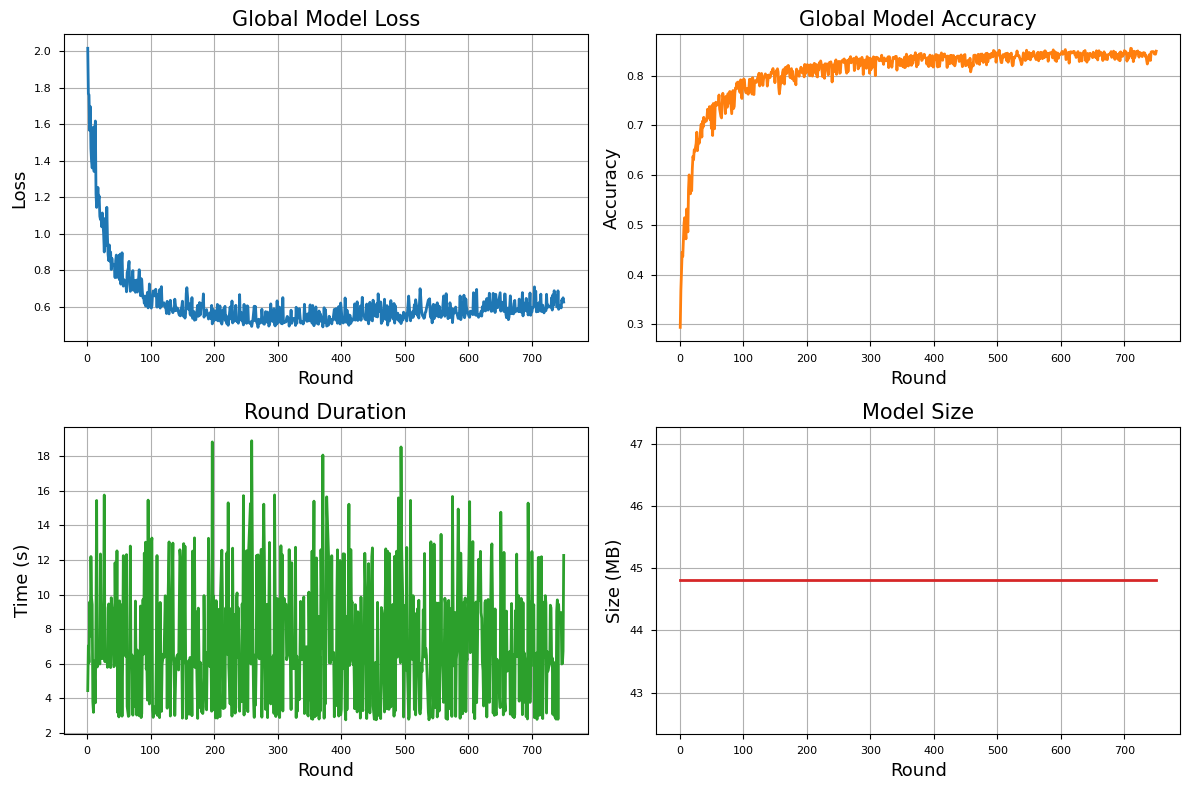

Plot saved to training_metrics_FP16.png


In [ ]:
# Plot metrics
metrics_filename_int8 = "training_metrics_FP16.png"
plot_metrics(metrics, metrics_filename_int8)

In [ ]:
!zip -r /content/{run_save_dir}.zip /content/{run_save_dir}/
from google.colab import files
files.download(f"/content/{run_save_dir}.zip")
files.download(f"/content/{metrics_filename_int8}")
files.download(f"/content/{summary_filename}")

  adding: content/checkpoints/ (stored 0%)
  adding: content/checkpoints/best_model.pth (deflated 61%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def server_aggregate_models(clients):
    models = [x["local_model"].state_dict() for x in clients]
    averaged_model = copy.deepcopy(models[0])
    with torch.no_grad():
        for k in averaged_model.keys():
            averaged_model[k] = sum(m[k] for m in models) / len(models)
    return averaged_model


def quantification(clients) :
  models = clients["local_model"]
